We use Dropout layer to reduce overfitting and improve training. In this we actually switch off nodes in a particular node by randomly selecting the functional nodes in a particular layer. For eg. if there are 5 nodes we will select let's say 3 nodes randomly that will be functional and this is repeated for each epoch taking different nodes in different epochs.

So, this method is improving accuracy and reducing overfitting because each time nodes in hiddenlayer1 gives info to nodes in hidden layer 2 , the nodes focus gets divided in each epoch as it is not sure that if A2 will receive info from A1 or not in the upcoming epochs which reduces the focus and dependency. Hence, reducing overfitting.

Dropout and Random forest are very similar to each other, in RF we randomly select rows/columns and train a decision tree. in each epoch a different decision tree is trained similarly here we are training different NN in each epoch on the same dataset.

https://jmlr.org/papers/volume15/srivastava14a/srivastava14a.pdf

In [4]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

## Regression problm

In [5]:
x_train = np.linspace(-1,1,20)

In [6]:
x_train

array([-1.        , -0.89473684, -0.78947368, -0.68421053, -0.57894737,
       -0.47368421, -0.36842105, -0.26315789, -0.15789474, -0.05263158,
        0.05263158,  0.15789474,  0.26315789,  0.36842105,  0.47368421,
        0.57894737,  0.68421053,  0.78947368,  0.89473684,  1.        ])

In [7]:
x_train.shape

(20,)

In [8]:
y_train = np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  ,
                    -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475,
                    -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415,
                    0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])

In [9]:
x_test = np.linspace(-1,1,20)

In [10]:
x_test

array([-1.        , -0.89473684, -0.78947368, -0.68421053, -0.57894737,
       -0.47368421, -0.36842105, -0.26315789, -0.15789474, -0.05263158,
        0.05263158,  0.15789474,  0.26315789,  0.36842105,  0.47368421,
        0.57894737,  0.68421053,  0.78947368,  0.89473684,  1.        ])

In [11]:
y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
                   -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,
                   0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,
                   0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])

In [12]:
import matplotlib.pyplot as plt


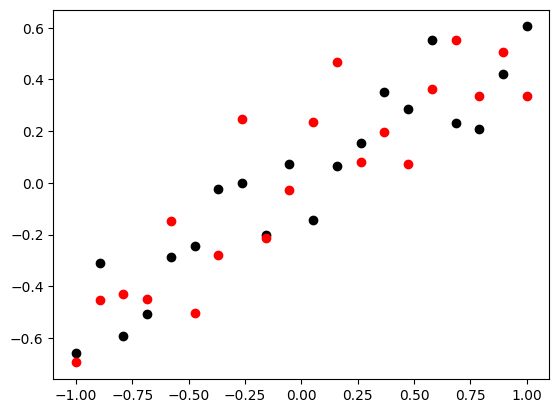

In [13]:
plt.scatter(x_train,y_train , c = "black", label = "Train")
plt.scatter(x_test,y_test, c="red",label = "Test")

In [14]:
model = Sequential()

In [101]:
model.add(Dense(128, input_dim = 1, activation = "relu"))
model.add(Dense(128, activation = "relu"))
model.add(Dense(1, activation = "linear"))

Validation loss means the how well model performs on test data

In [102]:
model.compile(loss = "mse", optimizer= "adam", metrics = ["mse"])

In [103]:
history = model.fit(x_train,y_train, epochs = 500, validation_data = (x_test,y_test),verbose = False)

In [104]:
 # evaluate the model
train_mse = model.evaluate(x_train, y_train, verbose=0)
test_mse = model.evaluate(x_test, y_test, verbose=0)
print('Train: {}, Test: {}'.format(train_mse, test_mse))

Train: [0.010379742830991745, 0.010379742830991745], Test: [0.03587385267019272, 0.03587385267019272]


In [105]:
y_pred = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


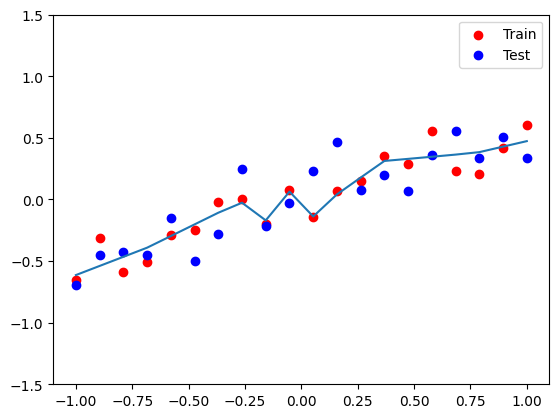

In [106]:
plt.figure()
plt.scatter(x_train, y_train, c='red', label='Train')
plt.scatter(x_test, y_test, c='blue', label='Test')
plt.plot(x_test, y_pred)
plt.legend()
plt.ylim((-1.5, 1.5))         ## use to specify the range in y axis.
plt.show()

We can see there is overfitting in the data. (Generally when epochs are huge)

## Dropout model

In [27]:
model.add(Dense(128, input_dim = 1, activation = "relu"))
model.add(Dropout(0.2))
model.add(Dense(128, activation = "relu"))
model.add(Dropout(0.2))
model.add(Dense(1, activation = "linear"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model.compile(loss = "mse", optimizer= "adam", metrics = ["mse"])

In [29]:
history1 = model.fit(x_train,y_train, epochs = 500, validation_data = (x_test,y_test),verbose = False)

In [30]:
 # evaluate the model
train_mse = model.evaluate(x_train, y_train, verbose=0)
test_mse = model.evaluate(x_test, y_test, verbose=0)
print('Train: {}, Test: {}'.format(train_mse, test_mse))

Train: [0.01356594730168581, 0.01356594730168581], Test: [0.03438211604952812, 0.03438211604952812]


In [31]:
y_pred1 = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


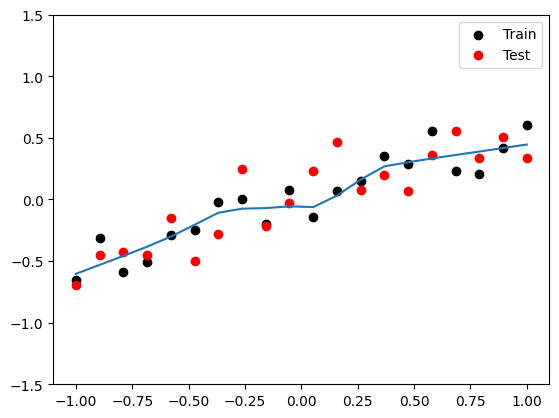

In [32]:
plt.figure()
plt.scatter(x_train, y_train, c='black', label='Train')
plt.scatter(x_test, y_test, c='red', label='Test')
plt.plot(x_test, y_pred1)
plt.legend()
plt.ylim((-1.5, 1.5))         ## use to specify the range in y axis.
plt.show()

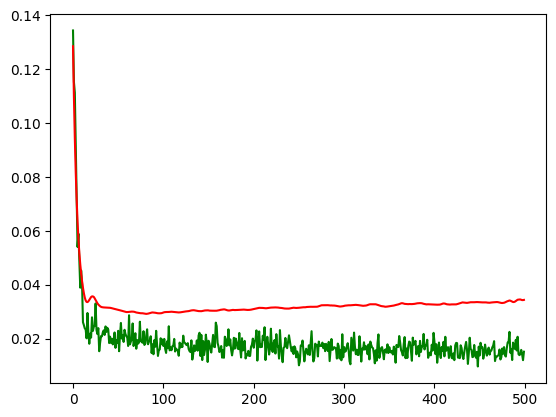

In [33]:
plt.plot(history1.history["mse"],color="green")
plt.plot(history1.history["val_loss"],color="red")

## Changing dropout ratio

In [15]:
model1 = Sequential()

In [16]:
model1.add(Dense(128, input_dim = 1, activation = "relu"))
model1.add(Dropout(0.7))
model1.add(Dense(128, activation = "relu"))
model1.add(Dropout(0.7))
model1.add(Dense(1, activation = "linear"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model1.compile(loss = "mse", optimizer= "adam", metrics = ["mse"])

In [18]:

history = model1.fit(x_train,y_train, epochs = 500, validation_data = (x_test,y_test),verbose = False)

In [19]:
 # evaluate the model
train_mse = model1.evaluate(x_train, y_train, verbose=0)
test_mse = model1.evaluate(x_test, y_test, verbose=0)
print('Train: {}, Test: {}'.format(train_mse, test_mse))

Train: [0.02074442431330681, 0.02074442431330681], Test: [0.03612517565488815, 0.03612517565488815]


In [20]:
y_pred2 = model1.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


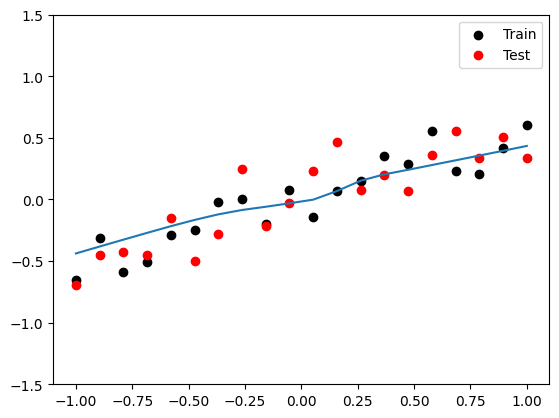

In [21]:
plt.figure()
plt.scatter(x_train, y_train, c='black', label='Train')
plt.scatter(x_test, y_test, c='red', label='Test')
plt.plot(x_test, y_pred2)
plt.legend()
plt.ylim((-1.5, 1.5))         ## use to specify the range in y axis.
plt.show()

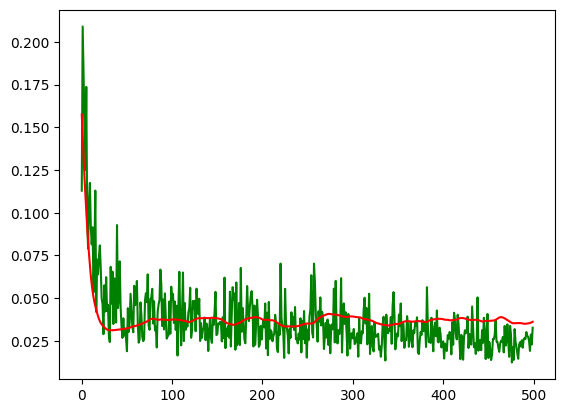

In [26]:
plt.plot(history.history["mse"],color="green")
plt.plot(history.history["val_loss"],color="red")

1. increasing the drpout layer from 0.2 to 0.7
2. training error increased from 0.0136 to 0.0207
3. testing mse inc from 0.0344 to 0.0361

This suggests that 0.7 is too aggressive for the dataset leading to underfitting, where the model is too simple to capture the patterns

1. Inc dropout ratio to reduce overfitting
2. dec dropout ratio to reduce underfitting
3. Good strategy is to start applying dropout from the last layer and then applying on other layers for improvement in predictions
4. For CNN - p : (40-50%)
5. for ANN p : (10-50%)
6. generally model does not perform wll if p>0.5

DRAWBACKS OF DROPOUTS IN REG/CLASSIFICATION
1. convergence slow
2. Loss function changes , loss function keeps on varying due to which gradient calculation becomes difficult.
